In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

<h1>Energy Calibration</h1>
Založeno na známých pozicích peaků zjištěných pomocí peak fitu

In [3]:
df_calib = pd.read_csv("data_naitl/calib_data.txt", sep = "\t")

In [4]:
df_calib

,CHANNEL,ENERGY
0,104,121.78170
1,105,122.06065
2,238,295.22400
3,276,344.27850
4,283,351.93200
5,404,511.00000
6,456,583.18700
7,478,609.31200
8,520,661.65530
9,602,785.96000


<h2>Linear fit</h2>

In [5]:
x = df_calib["CHANNEL"].to_numpy().reshape((-1, 1))
y = df_calib["ENERGY"].to_numpy()

X = df_calib['CHANNEL']
Y = df_calib['ENERGY']

# Fit data
calib_fit = LinearRegression().fit(x, y)


In [6]:
# Predict Y values
Y_pred = calib_fit.predict(X.values.reshape(-1, 1))

# Calculate residuals
residuals = Y - Y_pred

# Calculate standard error of the residuals
std_err = np.std(residuals)

# Calculate the standard error of the coefficients
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add a bias term (intercept)
cov_matrix = np.linalg.inv(X_b.T @ X_b) * std_err**2
se = np.sqrt(np.diag(cov_matrix))

# Extract the standard errors of the intercept and slope
se_intercept, se_slope = se

# Print the fit parameters and their errors
print("Intercept:", calib_fit.intercept_, "±", se_intercept)
print("Slope:", calib_fit.coef_[0], "±", se_slope)

Intercept: -37.924577352873484 ± 5.847000998184691
Slope: 1.3689571921228507 ± 0.0062814271022541765


<h2>Plot energy calibration</h2>

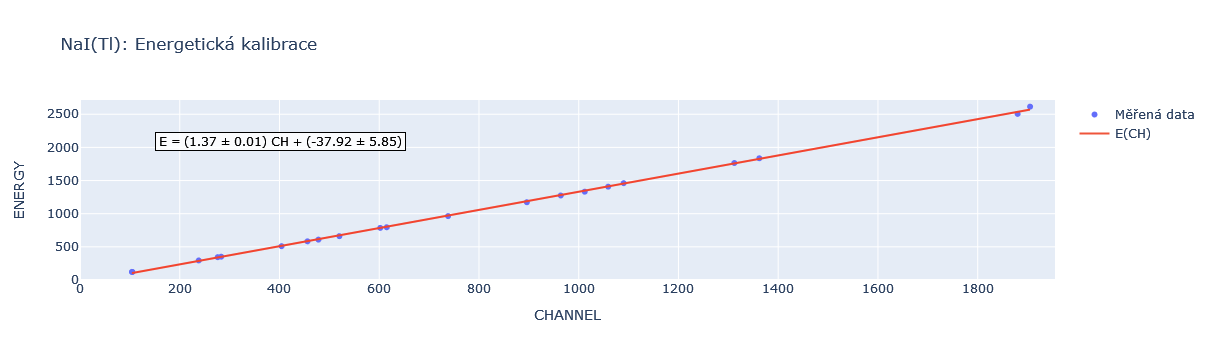

In [15]:
import numpy as np
import plotly.graph_objects as go

# Define the scatter plot with a specified legend
data_trace = go.Scatter(
    x=df_calib['CHANNEL'],
    y=df_calib['ENERGY'],
    mode='markers',
    name='Měřená data'  # Legend name for the scatter plot
)

# Round the coefficients and uncertainties to 2 significant digits
slope = round(calib_fit.coef_[0], 2)
se_slope_rounded = round(se_slope, 2)
intercept = round(calib_fit.intercept_, 2)
se_intercept_rounded = round(se_intercept, 2)

# Create the annotation text
annotation_text = f"E = ({slope} ± {se_slope_rounded}) CH + ({intercept} ± {se_intercept_rounded})"

# Define the linear fit line
fit_line_trace = go.Scatter(
    x=df_calib['CHANNEL'],
    y=Y_pred,
    mode='lines',
    name='E(CH)'
)

# Define the upper and lower bounds of the fit line error
fit_upper_bound = Y_pred + std_err
fit_lower_bound = Y_pred - std_err

# Define the shaded area for the fit error
fit_error_trace = go.Scatter(
    x=np.concatenate([df_calib['CHANNEL'], df_calib['CHANNEL'][::-1]]),
    y=np.concatenate([fit_upper_bound, fit_lower_bound[::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line=dict(color='rgba(255, 0, 0, 0)'),
    showlegend=False,
    name='Fit Error'
)

# Combine the traces
data = [data_trace, fit_line_trace, fit_error_trace]

# Define the layout
layout = go.Layout(
    title='NaI(Tl): Energetická kalibrace',
    xaxis=dict(
        title='CHANNEL',
        range=[0, max(df_calib['CHANNEL'])+50]  # Ensure x-axis starts at 0
    ),
    yaxis=dict(
        title='ENERGY',
        range=[0, max(df_calib['ENERGY'])+100]  # Ensure y-axis starts at 0
    ),
    showlegend=True,
    annotations=[
        dict(
            x=0.2 * (max(df_calib['CHANNEL']) + min(df_calib['CHANNEL'])),  # Place near the center
            y=0.8 * max(df_calib['ENERGY']),  # Adjust position as needed
            text=annotation_text,
            showarrow=False,
            font=dict(size=12, color="black"),
            align="center",
            bgcolor="rgba(255, 255, 255, 0.8)",
            bordercolor="black",
            borderwidth=1
        )
    ]
)

# Create the figure
fig = go.Figure(data=data, layout=layout)

# Display the figure
fig.show()


<h2>Quadratic fit</h2>

Calibration coefficients (a, b, c) and their errors:
a (quadratic term): 2.33053704313522e-05 ± 1.0760204704426858e-05
b (linear term): 1.324083047533403 ± 0.021581862957660597
c (constant term): -23.289056202524637 ± 8.792075503260225


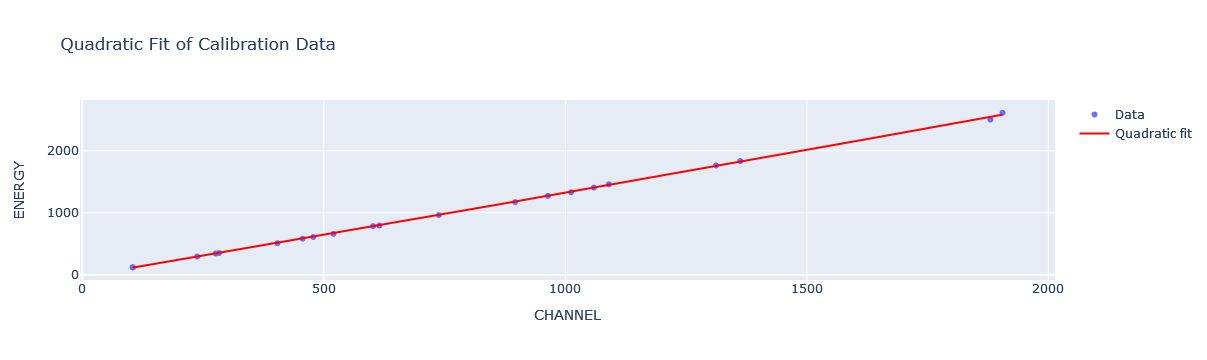

In [16]:
# Extract X and Y values
X = df_calib["CHANNEL"]
Y = df_calib["ENERGY"]

# Perform quadratic fit with errors
coefficients, cov_matrix = np.polyfit(X, Y, 2, cov=True)  # 2 for quadratic

# Calculate the standard errors of the coefficients
errors = np.sqrt(np.diag(cov_matrix))

# Print the calibration coefficients and their errors
print("Calibration coefficients (a, b, c) and their errors:")
print(f"a (quadratic term): {coefficients[0]} ± {errors[0]}")
print(f"b (linear term): {coefficients[1]} ± {errors[1]}")
print(f"c (constant term): {coefficients[2]} ± {errors[2]}")

# Generate data for the fit line
X_fit = np.linspace(X.min(), X.max(), 100)
Y_fit = np.poly1d(coefficients)(X_fit)

# Create Plotly traces
data_trace = go.Scatter(
    x=X, 
    y=Y, 
    mode='markers', 
    name='Data'
)

fit_trace = go.Scatter(
    x=X_fit, 
    y=Y_fit, 
    mode='lines', 
    name='Quadratic fit',
    line=dict(color='red')
)

# Create layout
layout = go.Layout(
    title='Quadratic Fit of Calibration Data',
    xaxis=dict(title='CHANNEL'),
    yaxis=dict(title='ENERGY')
)

# Combine traces and layout into a figure
fig = go.Figure(data=[data_trace, fit_trace], layout=layout)

# Display the plot
fig.show()

In [15]:
# Print the calibration coefficients
print("Calibration coefficients (a, b, c):")
print(f"a (quadratic term): {coefficients[0]}")
print(f"b (linear term): {coefficients[1]}")
print(f"c (constant term): {coefficients[2]}")

Calibration coefficients (a, b, c):
a (quadratic term): 2.33053704313522e-05
b (linear term): 1.324083047533403
c (constant term): -23.289056202524637
